# 3 - Emotion Detection - Computer Vision

<img src='https://www.psychologicalscience.org/redesign/wp-content/uploads/2018/04/PAFF_040918_emotionspectrum2.jpg'>

Bu çalışmada yüz görsellerinden duygu sınıfını tahmin eden bir computer vision modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri hazırlama
4. CNN modeli kurma
5. Modeli eğitme
6. Modeli değerlendirme
7. Örnek tahmin
8. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen emotion detection datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Emotion Detection.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'drive', 'train', 'test', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde train ve test klasör yapılarını inceleyeceğim.

In [6]:
train_dir = '/content/train'
test_dir = '/content/test'

print('Train classes:', os.listdir(train_dir))
print('Test classes:', os.listdir(test_dir))

Train classes: ['disgusted', 'surprised', 'neutral', 'sad', 'happy', 'angry', 'fearful']
Test classes: ['disgusted', 'surprised', 'neutral', 'sad', 'happy', 'angry', 'fearful']


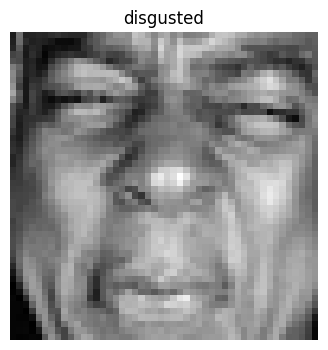

In [7]:
sample_class = os.listdir(train_dir)[0]
sample_image_path = os.path.join(train_dir, sample_class, os.listdir(os.path.join(train_dir, sample_class))[0])

sample_image = plt.imread(sample_image_path)
plt.figure(figsize=(4,4))
plt.imshow(sample_image, cmap='gray')
plt.title(sample_class)
plt.axis('off')
plt.show()

## 3. Veri Hazırlama

In [8]:
# Bu bölümde klasörlerden görüntüleri okuyup model için uygun hale getireceğim.

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 4. CNN Modeli Kurma

In [10]:
# Bu bölümde duygu sınıflarını tahmin etmek için bir CNN modeli kuracağım.

In [11]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,911 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Modeli Eğitme

In [12]:
# Bu bölümde CNN modelini eğitim verisi ile eğiteceğim.

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.3065 - loss: 1.7841 - val_accuracy: 0.2274 - val_loss: 2.0690 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.3845 - loss: 1.5748 - val_accuracy: 0.3185 - val_loss: 1.7082 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.4325 - loss: 1.4694 - val_accuracy: 0.4748 - val_loss: 1.3812 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4563 - loss: 1.4106 - val_accuracy: 0.4433 - val_loss: 1.4297 - learning_rate: 0.0010
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4764 - loss: 1.3660 - val_accuracy: 0.5091 - val_loss: 1.2900 - learning_rate: 0.0010
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.4955 - loss: 1.3281 - val_accuracy: 0.4957 - val_loss: 1.3165 - learning_rate: 0.0010
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.5098 - l

## 6. Modeli Değerlendirme

In [14]:
# Bu bölümde modeli test verisi üzerinde değerlendirip accuracy sonucuna bakacağım.

In [15]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print('Test Accuracy:', test_accuracy)
print('Test Loss:', test_loss)

Test Accuracy: 0.592644214630127
Test Loss: 1.06504225730896


In [16]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
              precision    recall  f1-score   support

       angry       0.46      0.59      0.52       958
   disgusted       0.77      0.09      0.16       111
     fearful       0.49      0.19      0.27      1024
       happy       0.81      0.84      0.82      1774
     neutral       0.50      0.65      0.56      1233
         sad       0.47      0.51      0.49      1247
   surprised       0.75      0.69      0.72       831

    accuracy                           0.59      7178
   macro avg       0.61      0.51      0.51      7178
weighted avg       0.60      0.59      0.58      7178



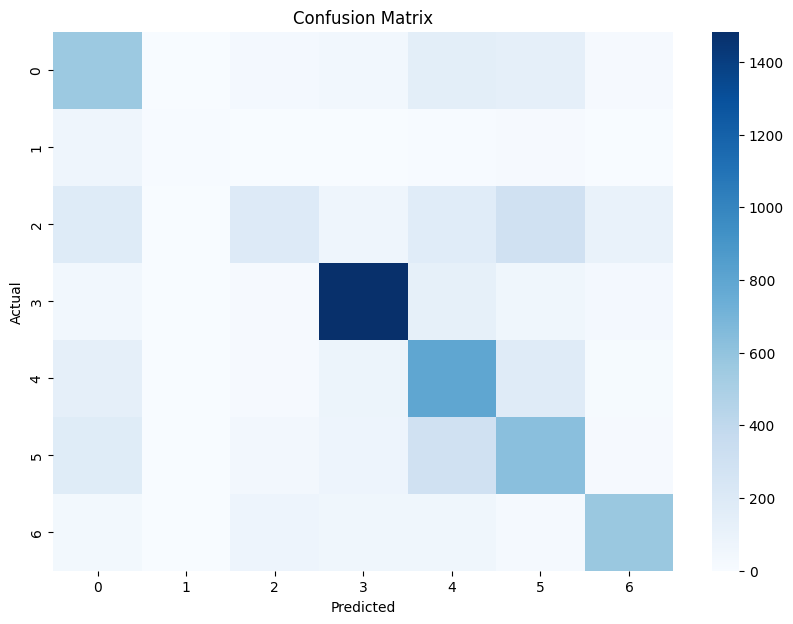

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Örnek Tahmin

In [18]:
# Bu bölümde test setinden bir yüz görseli için duygu tahmini yapacağım.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step


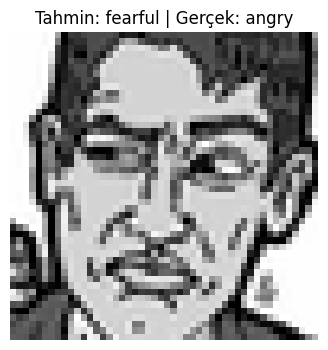

In [19]:
sample_images, sample_labels = next(test_generator)
sample_prediction = np.argmax(model.predict(sample_images[:1]), axis=1)[0]
true_label = np.argmax(sample_labels[0])
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(4,4))
plt.imshow(sample_images[0].reshape(48,48), cmap='gray')
plt.title(f'Tahmin: {class_names[sample_prediction]} | Gerçek: {class_names[true_label]}')
plt.axis('off')
plt.show()

## 8. Sonuç

Bu projede yüz ifadelerinden duygu sınıfını tahmin etmek için CNN tabanlı bir computer vision modeli kullanıldı. Elde edilen sonuçlara göre model 0.5926 accuracy değeri elde etti.